## K-Means Cluster Analysis

Emily Longmire

Note: no K-Means for mutations data since it is binary and it won't provide correct information

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

data=pd.read_csv("cleaned_dataset.csv")

Separate the data into 3 groups

In [2]:
# missing values won't work for k-means - drop rows with missing values
data.dropna(inplace=True)

# clinical attributes
clinical_cols = data.columns[489:518]
clinical_data = data[clinical_cols].copy()

# gene mutations (not used here)
mutation_cols = [col for col in data.columns if col.endswith("_mut")]

# gene expressions
expression_cols = [col for col in data.columns if col not in clinical_cols and col not in mutation_cols]
expressions_data = data[expression_cols].copy()

Encode categorical columns

In [3]:
death_from_cancer = clinical_data["death_from_cancer"].copy()

# drop predictor columns and redundant columns
clinical_data=clinical_data.drop(columns = ["overall_survival","death_from_cancer","event_observed","overall_survival_months","er_status_measured_by_ihc","her2_status_measured_by_snp6","3-gene_classifier_subtype","cohort"])

categorical_columns = ["type_of_breast_surgery", "cancer_type", "cancer_type_detailed","cellularity", "pam50_+_claudin-low_subtype","er_status", "her2_status", "inferred_menopausal_state", "integrative_cluster", "primary_tumor_laterality","pr_status"]

# label encode categorical columns
encoders = {}
for col in categorical_columns:
    le = LabelEncoder()

    # save the original (true) labels for plotting
    clinical_data[f"true_{col}"] = clinical_data[col]
    clinical_data[col] = le.fit_transform(clinical_data[col])
    encoders[col] = le

Drop true label columns for now

In [4]:
# drop the original (true) columns for clustering - add back later
true_cols = [col for col in clinical_data.columns if col.startswith("true_")]
clinical_data_encoded = clinical_data.drop(true_cols, axis=1)

## Clinical Clustering

Test different K values and pick the best one based on elbow plot

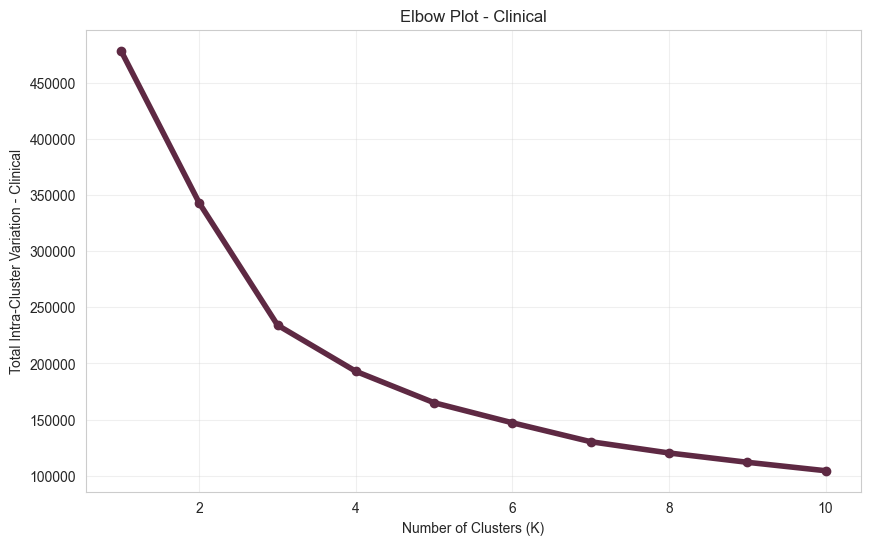

In [5]:
# record total intra-cluster variation
clinical_ticv = []

# test various values of K to find the best one
for k in range(1, 11):
    clinical_kmeans = KMeans(n_clusters=k, n_init=20, random_state=57)

    # fit kmeans algorithm
    clinical_kmeans.fit(clinical_data_encoded)

    # record total intra-cluster variation
    clinical_ticv.append(clinical_kmeans.inertia_)

# elbow plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, 11), clinical_ticv, linewidth=4, marker="o", c="#5e2943")
ax.set_title("Elbow Plot - Clinical")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Total Intra-Cluster Variation - Clinical")
ax.grid(True, alpha=0.3)
plt.show()

Choose K=3 based on the plot

In [6]:
# recalculate/fit k-means with K=3
clinical_kmeans = KMeans(n_clusters=3, n_init=20, random_state=57)
y_clinical_kmeans = clinical_kmeans.fit_predict(clinical_data_encoded)

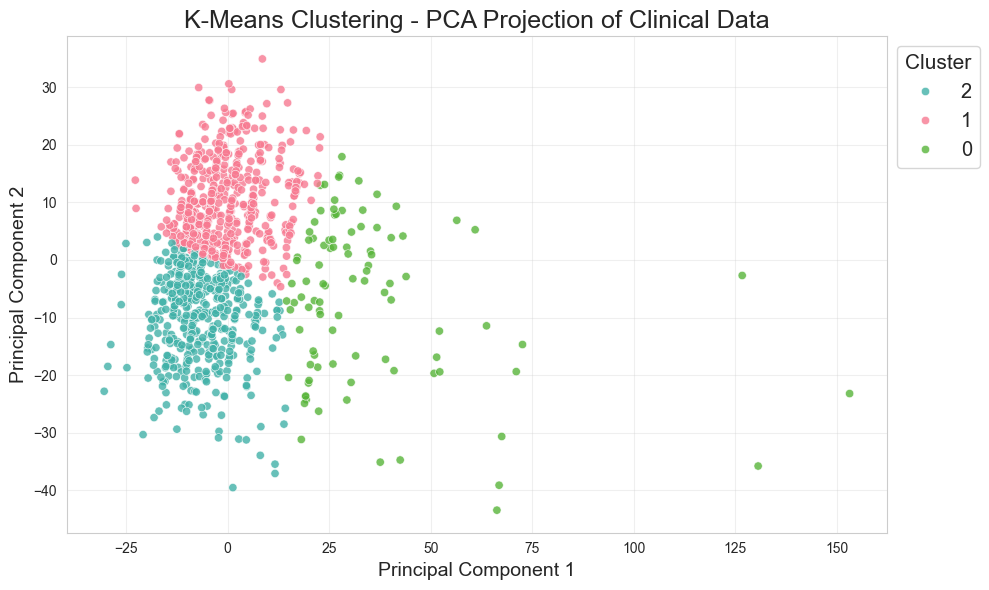

In [7]:
# apply PCA for visualization
pca = PCA(n_components=2)
clinical_pca = pca.fit_transform(clinical_data_encoded)
clinical_pca_df = pd.DataFrame({"PC1": clinical_pca[:, 0], "PC2": clinical_pca[:, 1], "Cluster": y_clinical_kmeans.astype(str)})

# add cluster column after PCA so it doesn't add influence
clinical_data_encoded["cluster"] = y_clinical_kmeans

# color palette
colors=["#41b1a8","#f77a91","#57b439"]

# plot PCA projection of the clusters
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=clinical_pca_df, x="PC1", y="PC2", hue="Cluster", palette=colors, alpha=0.8, ax=ax)
ax.set_xlabel("Principal Component 1", fontsize=14)
ax.set_ylabel("Principal Component 2", fontsize=14)
ax.set_title("K-Means Clustering - PCA Projection of Clinical Data", fontsize=18)
ax.legend(title="Cluster", bbox_to_anchor=(1, 1), loc="upper left", fontsize="x-large", title_fontsize="15")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# decode categorical columns to get original labels
for col, encoder in encoders.items():
    if col in clinical_data_encoded.columns:
        clinical_data_encoded[col] = encoder.inverse_transform(clinical_data_encoded[col])

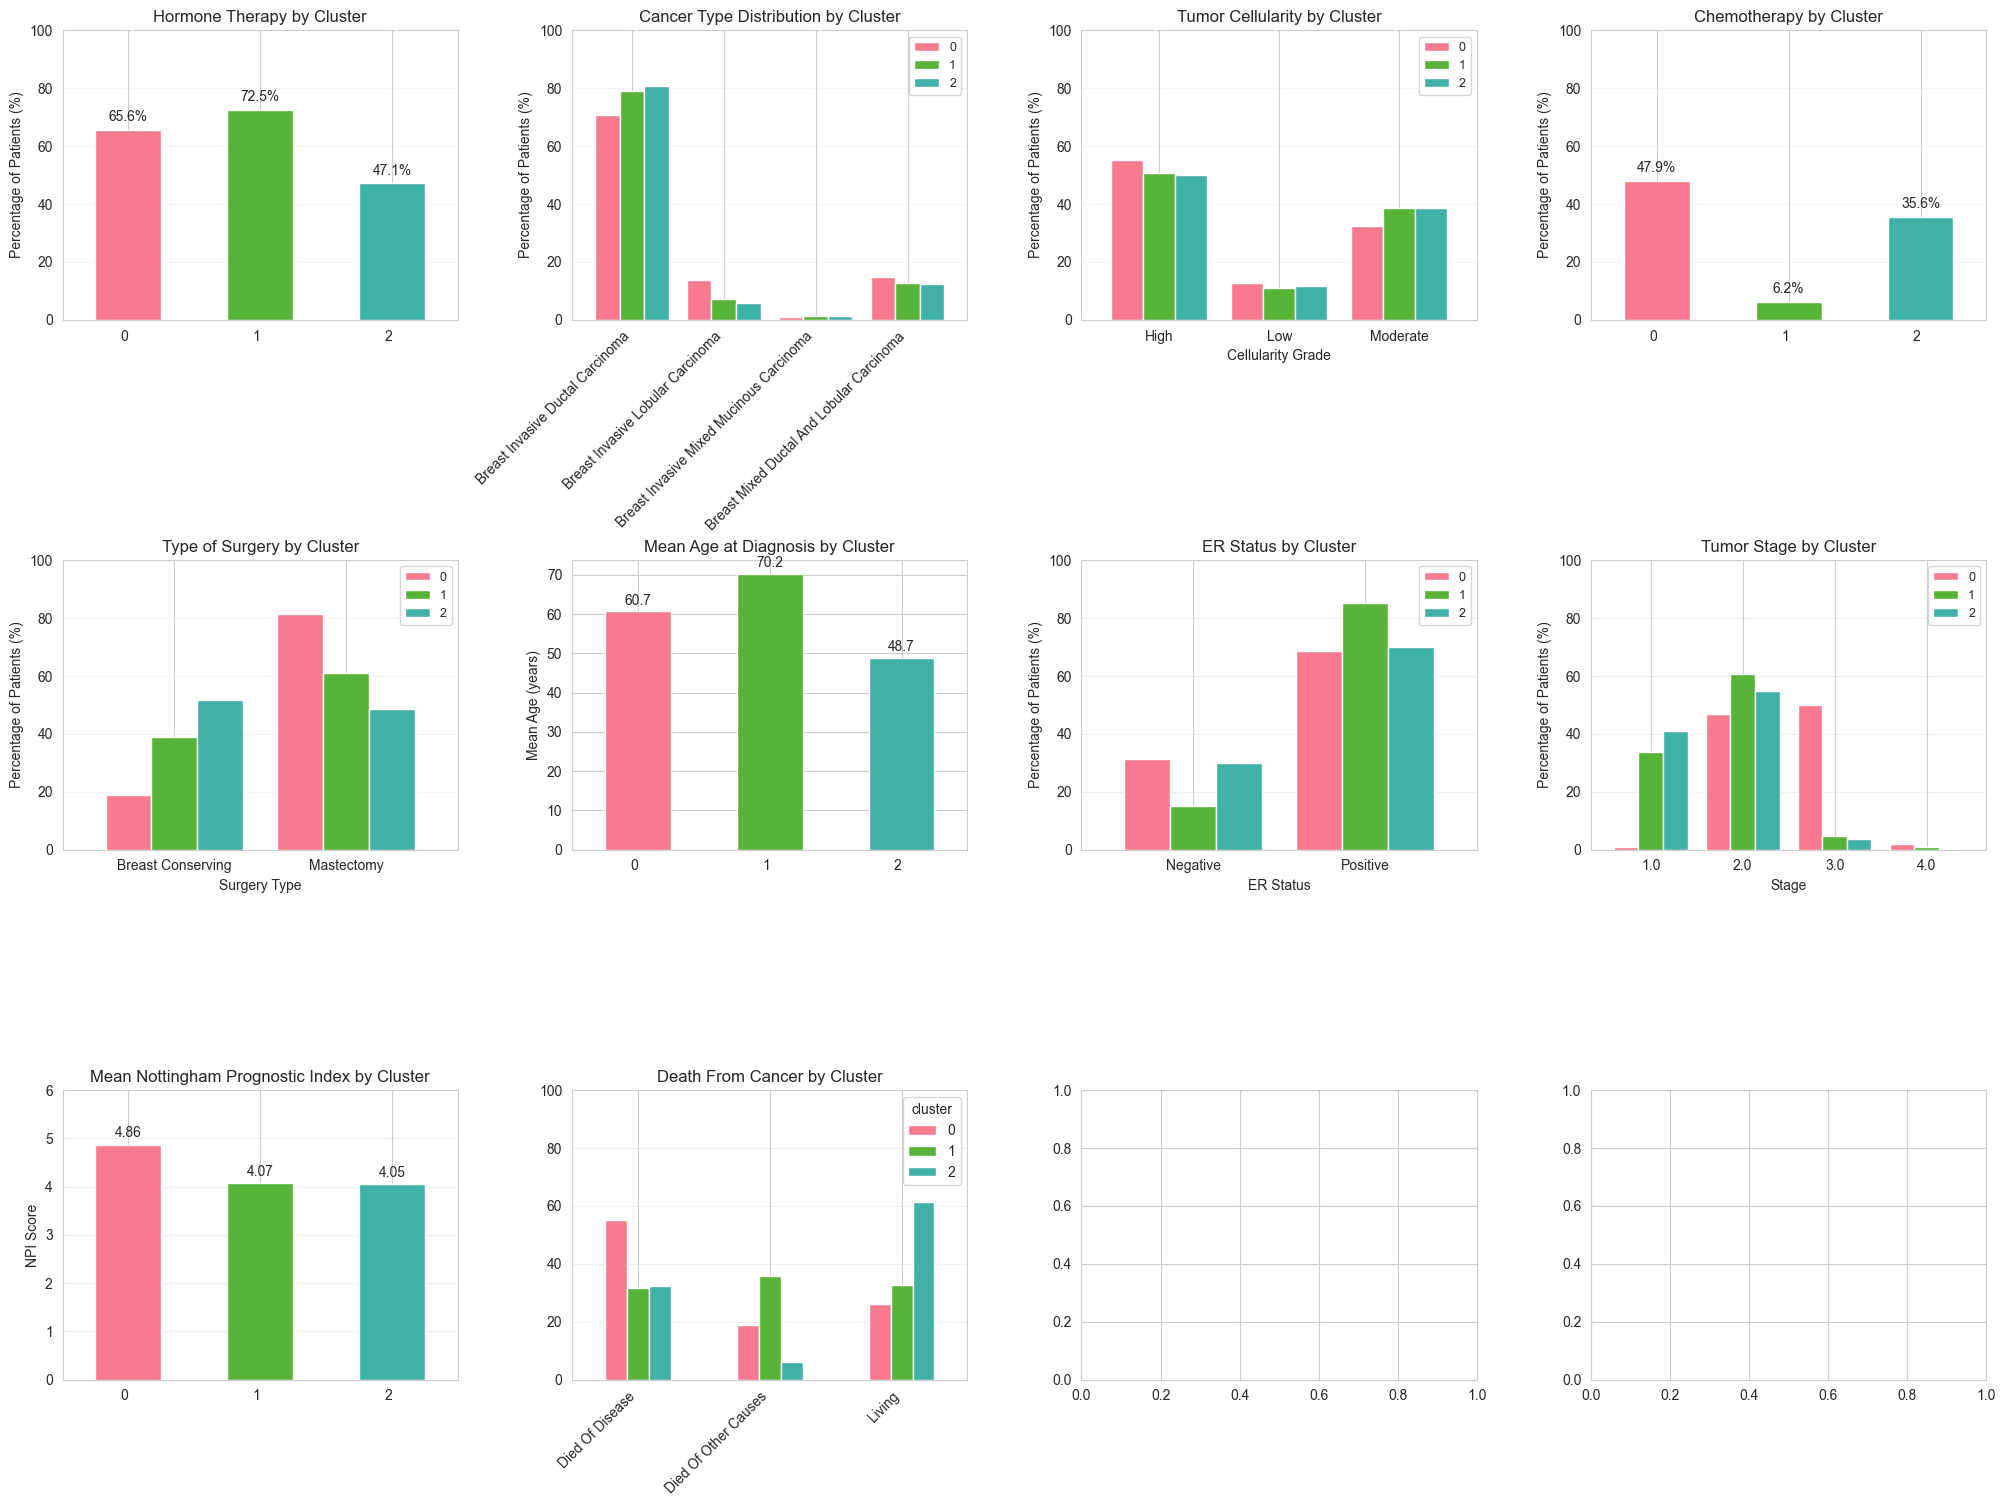

In [9]:
clinical_data_encoded["death_from_cancer"] = death_from_cancer

# get cluster sizes
cluster_sizes = clinical_data_encoded.groupby("cluster").size()

# calculate cluster proportions/summary statistics
death_from_cancer_prop = (clinical_data_encoded.groupby("cluster")["death_from_cancer"].value_counts(normalize=True).mul(100).round(2).unstack(fill_value=0))

hormone_therapy_prop = clinical_data_encoded.groupby("cluster")["hormone_therapy"].mean() * 100

chemotherapy_prop = clinical_data_encoded.groupby("cluster")["chemotherapy"].mean() * 100

cancer_type_detailed_prop = clinical_data_encoded.groupby(["cluster", "cancer_type_detailed"]).size().unstack(fill_value=0)
cancer_type_detailed_prop = cancer_type_detailed_prop.div(cluster_sizes, axis=0) * 100

cellularity_prop = clinical_data_encoded.groupby(["cluster", "cellularity"]).size().unstack(fill_value=0)
cellularity_prop = cellularity_prop.div(cluster_sizes, axis=0) * 100

surgery_prop = clinical_data_encoded.groupby(["cluster", "type_of_breast_surgery"]).size().unstack(fill_value=0)
surgery_prop = surgery_prop.div(cluster_sizes, axis=0) * 100

age_means = clinical_data_encoded.groupby("cluster")["age_at_diagnosis"].mean()

er_status_prop = clinical_data_encoded.groupby(["cluster", "er_status"]).size().unstack(fill_value=0)
er_status_prop = er_status_prop.div(cluster_sizes, axis=0) * 100

tumor_stage_prop = clinical_data_encoded.groupby(["cluster", "tumor_stage"]).size().unstack(fill_value=0)
tumor_stage_prop = tumor_stage_prop.div(cluster_sizes, axis=0) * 100

nottingham_means = clinical_data_encoded.groupby("cluster")["nottingham_prognostic_index"].mean()

# create figure and axes
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

# consistent order and colors
cluster_order = [0, 1, 2]
clinical_colors = [ "#f77a91","#57b439","#41b1a8"]

# hormone therapy by cluster
ax = axes[0, 0]
hormone_therapy_prop = hormone_therapy_prop.reindex(cluster_order)
bars = hormone_therapy_prop.plot(kind="bar", ax=ax, color=clinical_colors)
ax.set_title("Hormone Therapy by Cluster")
ax.set_xlabel("")
ax.set_ylabel("Percentage of Patients (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="right")
ax.grid(axis="y", alpha=0.2)
ax.set_ylim(0, 100)
for i, (cluster_name, value) in enumerate(hormone_therapy_prop.items()):
    ax.text(i, value + 2, f"{value:.1f}%", ha="center", va="bottom", fontsize=10)

# cancer type detailed by cluster
ax = axes[0, 1]
cancer_type_detailed_prop = cancer_type_detailed_prop.reindex(cluster_order)
cancer_type_detailed_prop.T.plot(kind="bar", ax=ax, color=clinical_colors, width=0.8)
ax.set_title("Cancer Type Distribution by Cluster")
ax.set_xlabel("")
ax.set_ylabel("Percentage of Patients (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(cluster_order, loc="best", fontsize=9)
ax.grid(axis="y", alpha=0.2)
ax.set_ylim(0, 100)

# cellularity by cluster
ax = axes[0, 2]
cellularity_prop = cellularity_prop.reindex(cluster_order)
cellularity_prop.T.plot(kind="bar", ax=ax, color=clinical_colors, width=0.8)
ax.set_title("Tumor Cellularity by Cluster")
ax.set_xlabel("Cellularity Grade")
ax.set_ylabel("Percentage of Patients (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(cluster_order, loc="best", fontsize=9)
ax.grid(axis="y", alpha=0.2)
ax.set_ylim(0, 100)

# chemotherapy by cluster
ax = axes[0, 3]
chemotherapy_prop = chemotherapy_prop.reindex(cluster_order)
bars = chemotherapy_prop.plot(kind="bar", ax=ax, color=clinical_colors)
ax.set_title("Chemotherapy by Cluster")
ax.set_xlabel("")
ax.set_ylabel("Percentage of Patients (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="right")
ax.grid(axis="y", alpha=0.2)
ax.set_ylim(0, 100)
for i, (cluster_name, value) in enumerate(chemotherapy_prop.items()):
    ax.text(i, value + 2, f"{value:.1f}%", ha="center", va="bottom", fontsize=10)

# type of breast surgery by cluster
ax = axes[1, 0]
surgery_prop = surgery_prop.reindex(cluster_order)
surgery_prop.T.plot(kind="bar", ax=ax, color=clinical_colors, width=0.8)
ax.set_title("Type of Surgery by Cluster")
ax.set_xlabel("Surgery Type")
ax.set_ylabel("Percentage of Patients (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(cluster_order, loc="best", fontsize=9)
ax.grid(axis="y", alpha=0.2)
ax.set_ylim(0, 100)

# mean age at diagnoses by cluster
ax = axes[1, 1]
age_means = age_means.reindex(cluster_order)
bars = age_means.plot(kind="bar", ax=ax, color=clinical_colors)
ax.set_title("Mean Age at Diagnosis by Cluster")
ax.set_xlabel("")
ax.set_ylabel("Mean Age (years)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="right")
for i, (cluster_name, value) in enumerate(age_means.items()):
    ax.text(i, value + 1, f"{value:.1f}", ha="center", va="bottom", fontsize=10)

# er status by cluster
ax = axes[1, 2]
er_status_prop = er_status_prop.reindex(cluster_order)
er_status_prop.T.plot(kind="bar", ax=ax, color=clinical_colors, width=0.8)
ax.set_title("ER Status by Cluster")
ax.set_xlabel("ER Status")
ax.set_ylabel("Percentage of Patients (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(cluster_order, loc="best", fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 100)

# tumor stage by cluster
ax = axes[1, 3]
tumor_stage_prop = tumor_stage_prop.reindex(cluster_order)
tumor_stage_prop.T.plot(kind="bar", ax=ax, color=clinical_colors, width=0.8)
ax.set_title("Tumor Stage by Cluster")
ax.set_xlabel("Stage")
ax.set_ylabel("Percentage of Patients (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(cluster_order, loc="best", fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 100)


# nottingham prognostic index by cluster
ax = axes[2, 0]
nottingham_means = nottingham_means.reindex(cluster_order)
bars = nottingham_means.plot(kind="bar", ax=ax, color=clinical_colors)
ax.set_title("Mean Nottingham Prognostic Index by Cluster")
ax.set_xlabel("")
ax.set_ylabel("NPI Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="right")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 6)
for i, (cluster_name, value) in enumerate(nottingham_means.items()):
    ax.text(i, value + 0.1, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# death from cancer by cluster
ax = axes[2, 1]
death_from_cancer_prop = death_from_cancer_prop.reindex(cluster_order)
bars = death_from_cancer_prop.T.plot(kind="bar", ax=ax, color=clinical_colors)
ax.set_title("Death From Cancer by Cluster")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 100)

plt.tight_layout(pad=0.5, h_pad=0.5, w_pad=0.5)
plt.show()

## Gene Expression Clustering

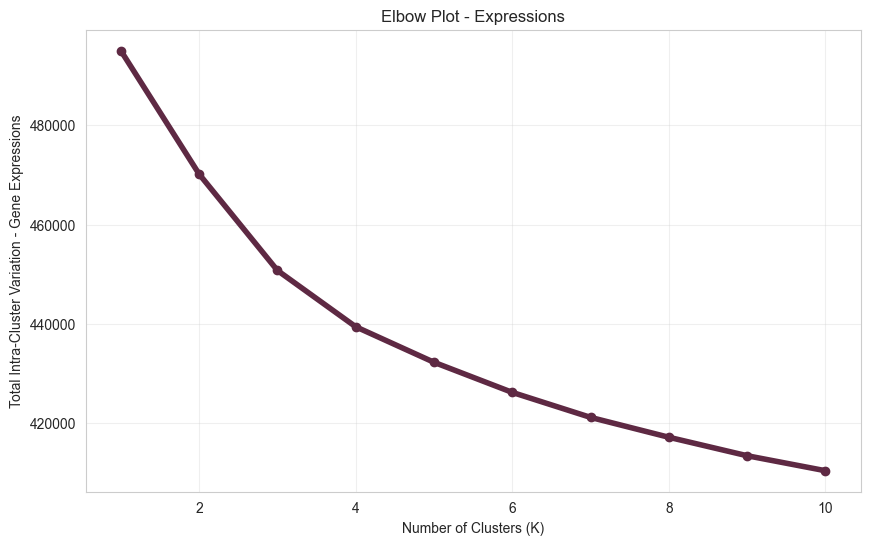

In [10]:
# record total intra-cluster variation
expressions_ticv = []

# test various values of K
for k in range(1, 11):
    expressions_kmeans = KMeans(n_clusters=k, n_init=10, random_state=57)

    # fit kmeans algorithm
    expressions_kmeans.fit(expressions_data)

    # record total intra-cluster variation
    expressions_ticv.append(expressions_kmeans.inertia_)

# elbow plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, 11), expressions_ticv, linewidth=4, marker="o", c="#5e2943")
ax.set_title("Elbow Plot - Expressions")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Total Intra-Cluster Variation - Gene Expressions")
ax.grid(True, alpha=0.3)
plt.show()

In [11]:
# choose k=3 based on elbow plot
expressions_kmeans = KMeans(n_clusters=3, n_init=10)
y_expressions_kmeans = expressions_kmeans.fit_predict(expressions_data)

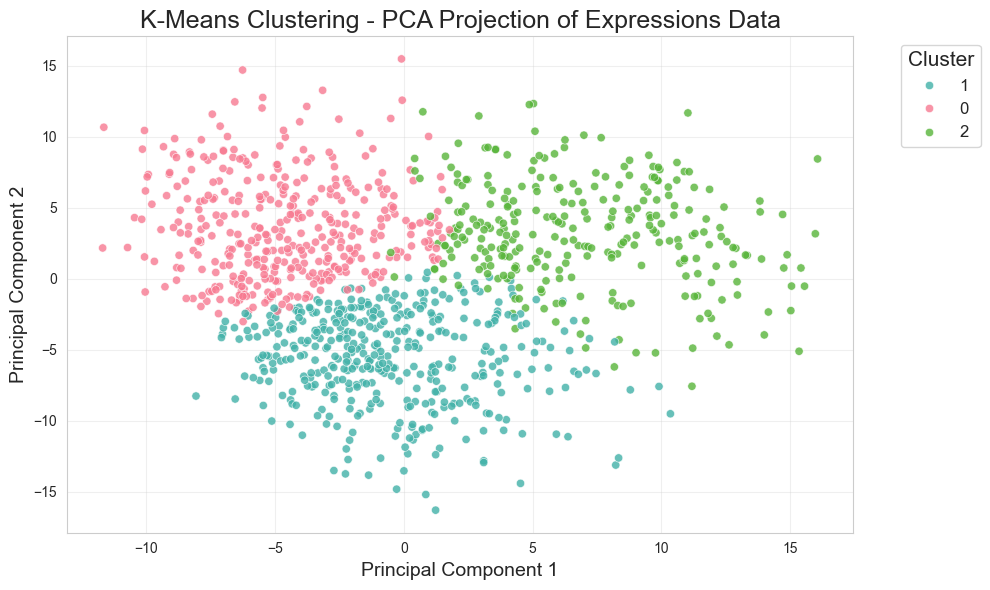

In [12]:
# apply PCA for visualization
pca = PCA(n_components=2)
expressions_pca = pca.fit_transform(expressions_data)
expressions_pca_df = pd.DataFrame({"PC1": expressions_pca[:, 0], "PC2": expressions_pca[:, 1], "Cluster": y_expressions_kmeans.astype(str)})

# add cluster column
expressions_data["cluster"] = y_expressions_kmeans

# palette
colors=["#41b1a8","#f77a91","#57b439"]

# plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=expressions_pca_df, x="PC1", y="PC2", hue="Cluster", palette=colors, alpha=0.8, ax=ax)
ax.set_xlabel("Principal Component 1", fontsize=14)
ax.set_ylabel("Principal Component 2", fontsize=14)
ax.set_title("K-Means Clustering - PCA Projection of Expressions Data", fontsize=18)
ax.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="large", title_fontsize="15")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Show top 5 genes for each cluster

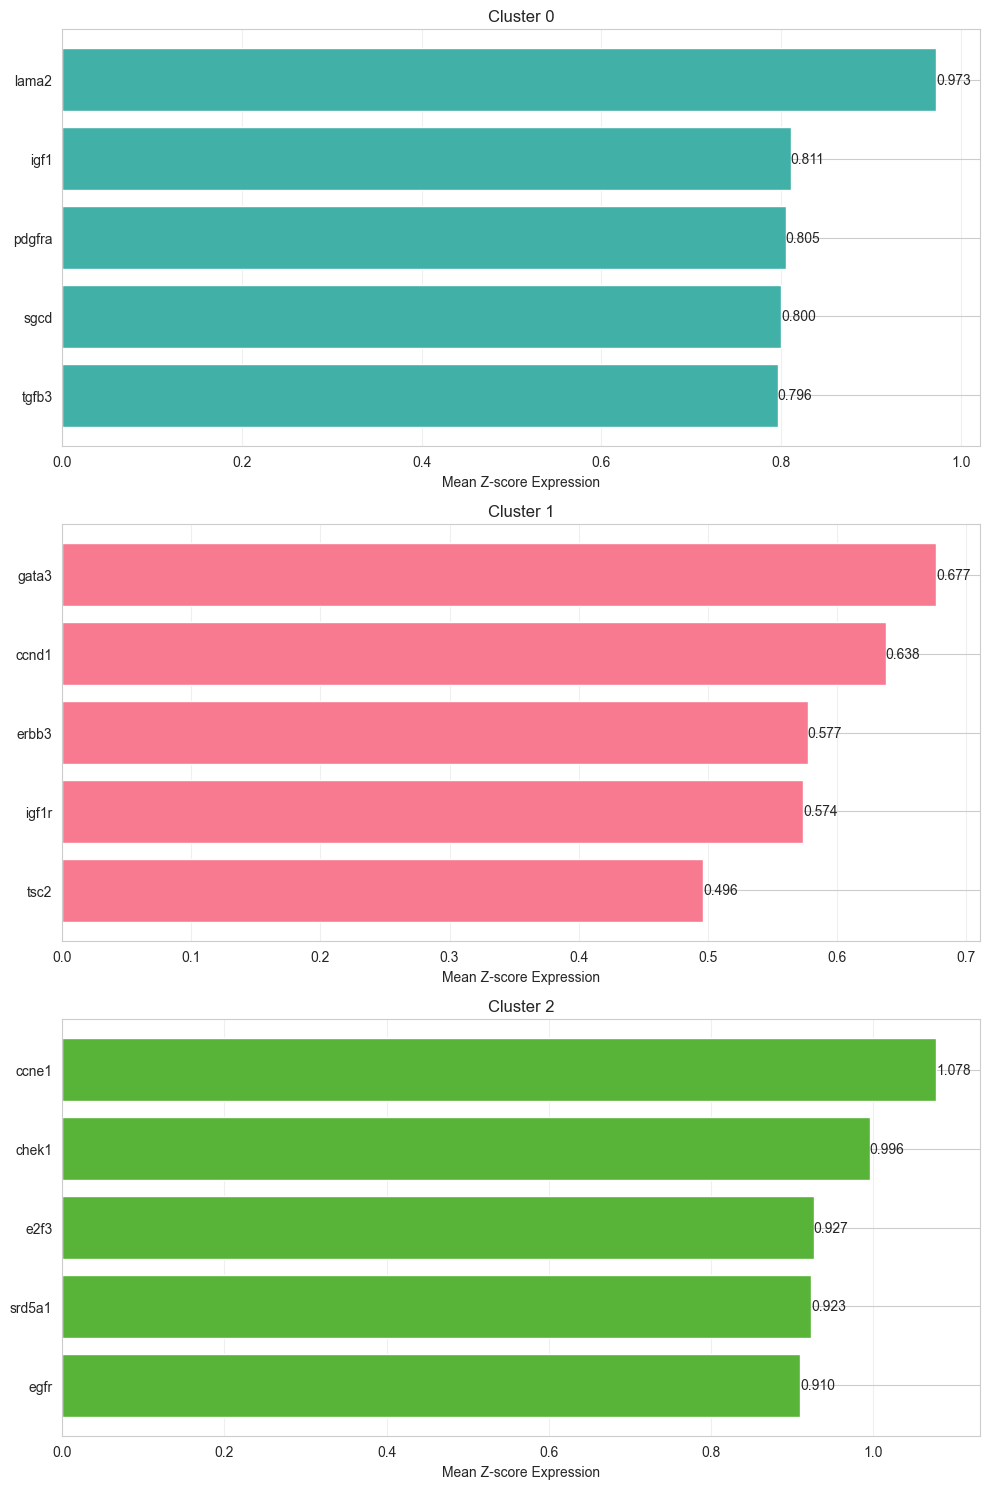

In [13]:
# get all gene columns minus cluster column
gene_columns = [col for col in expressions_data.columns if col != "cluster"]

# get unique clusters
clusters = sorted(expressions_data["cluster"].unique())
n_clusters = len(clusters)

# palette
expressions_colors = ["#41b1a8", "#f77a91", "#57b439", "#f6c900"]

# create figure and axes
fig, axes = plt.subplots(n_clusters, 1, figsize=(10, 15))

for i, cluster_id in enumerate(clusters):
    ax = axes[i]

    # filter data for current cluster
    cluster_data = expressions_data[expressions_data["cluster"] == cluster_id]
    n_samples = len(cluster_data)

    # calculate mean expression for each gene in this cluster
    gene_means = cluster_data[gene_columns].mean().sort_values(ascending=False)
    top_5_genes = gene_means.head(5)

    # plot
    bars = ax.barh(range(len(top_5_genes)), top_5_genes.values, color=expressions_colors[i % len(expressions_colors)])
    ax.set_yticks(range(len(top_5_genes)))
    ax.set_yticklabels(top_5_genes.index)
    ax.invert_yaxis()
    ax.set_xlabel("Mean Z-score Expression")
    ax.set_title(f"Cluster {cluster_id}", fontsize=12)
    ax.grid(axis="x", alpha=0.3)
    for i, (bar, val) in enumerate(zip(bars, top_5_genes.values)):
        ax.text(val, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

In [16]:
expressions_data["death_from_cancer"] = death_from_cancer

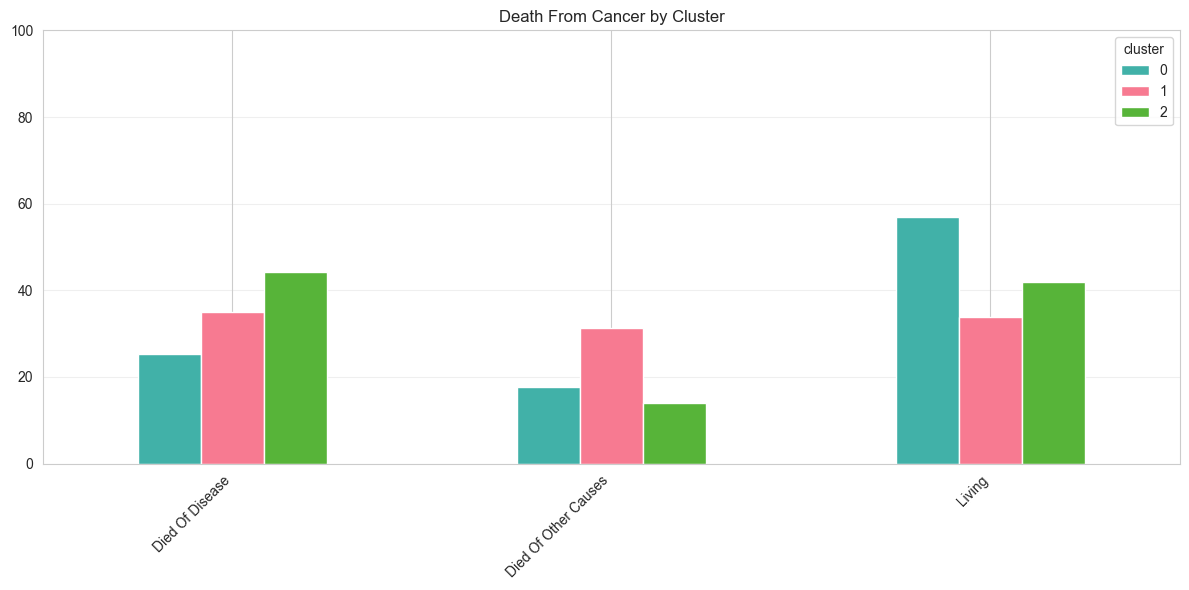

In [17]:
# calculate death from cancer proportions for each cluster
death_from_cancer_prop = (expressions_data.groupby("cluster")["death_from_cancer"].value_counts(normalize=True).mul(100).round(2).unstack(fill_value=0))

# plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = death_from_cancer_prop.T.plot(kind="bar", ax=ax, color=expressions_colors)
ax.set_title("Death From Cancer by Cluster")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Plot shows distinct differences in death_from_cancer